<a href="https://colab.research.google.com/github/cyrosouza/pos-tech-ia/blob/main/HandsOn-Aulas1e2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne -q

In [ ]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
arquivo_edf = "chb24_01.edf"
raw = mne.io.read_raw_edf(arquivo_edf, preload=True)
raw

Extracting EDF parameters from chb24_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_636/2877399466.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(arquivo_edf, preload=True)


<RawEDF | chb24_01.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

In [ ]:
print(raw.info)
print(raw.ch_names)
print(f"Taxa de amostragem: {raw.info['sfreq']} Hz")

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2074-01-25 16:26:28 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']
Taxa de amostragem: 256.0 Hz


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


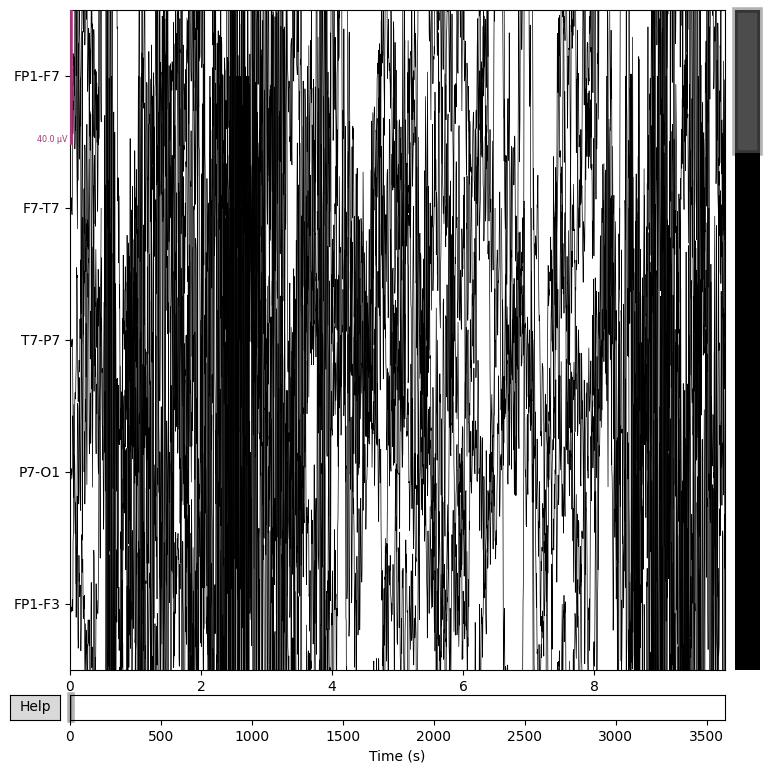

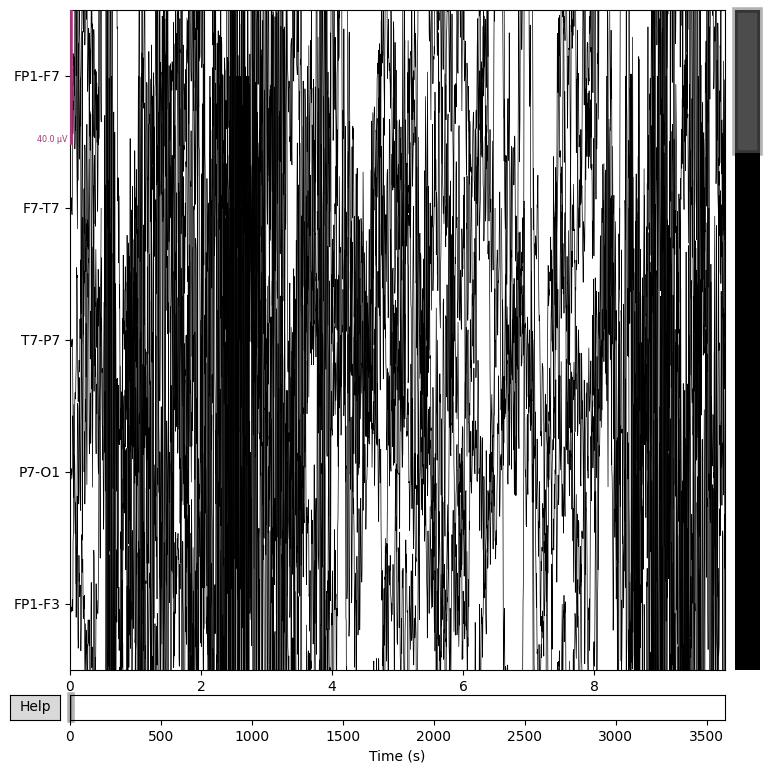

In [ ]:
raw.plot(duration=10, n_channels=5)

In [ ]:
data = raw.get_data()
data.shape

(23, 921600)

In [ ]:
print("Número de canais:", data.shape[0])
print("Número de amostras:", data.shape[1])

Número de canais: 23
Número de amostras: 921600


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


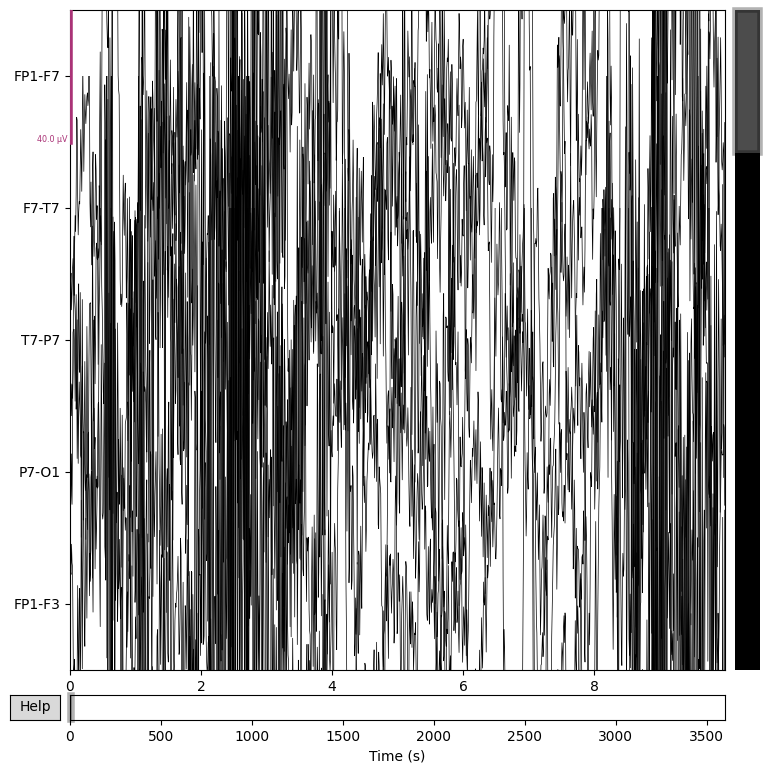

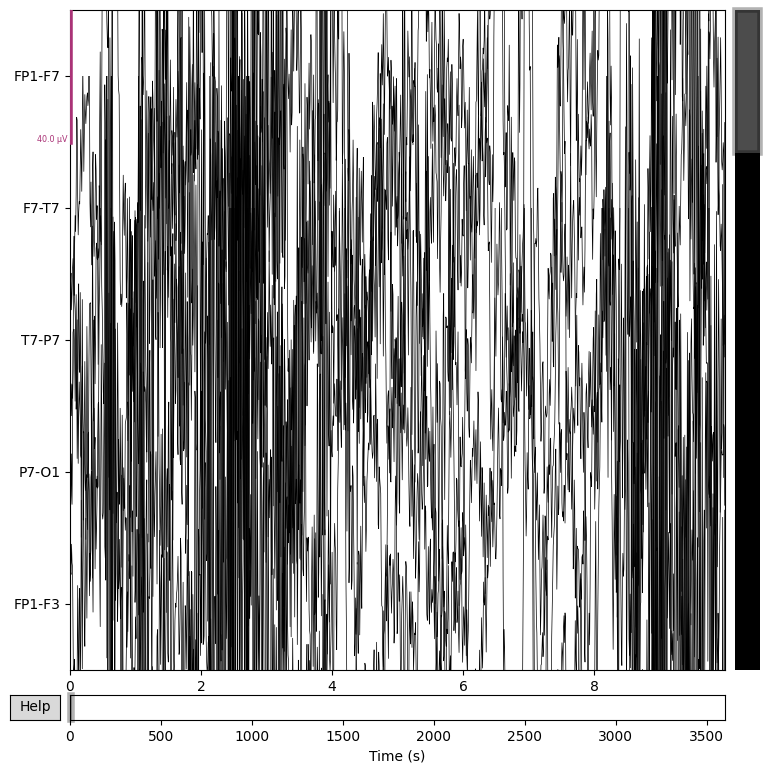

In [ ]:
raw_filtrado = raw.copy().filter(0.5, 40)
raw_filtrado.plot(duration=10, n_channels=5)

In [ ]:
data_filtrado = raw.get_data()
data_filtrado.shape

(23, 921600)

In [ ]:
with open("chb24-summary.txt", "r") as f:
    conteudo = f.readlines()

for linha in conteudo[:40]:
  print(linha.strip())

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb24_01.edf
Number of Seizures in File: 2
Seizure Start Time: 480 seconds
Seizure End Time: 505 seconds
Seizure Start Time: 2451 seconds
Seizure End Time: 2476 seconds

File Name: chb24_03.edf
Number of Seizures in File: 2
Seizure Start Time: 231 seconds
Seizure End Time: 260 seconds


In [ ]:
seizure_intervals_sec = [
    (480, 505),
    (2451, 2476)
]

sfreq = raw.info["sfreq"]

In [ ]:
canal_idx = 0
signal = data_filtrado[canal_idx]

In [ ]:
time = np.arange(len(signal)) / sfreq

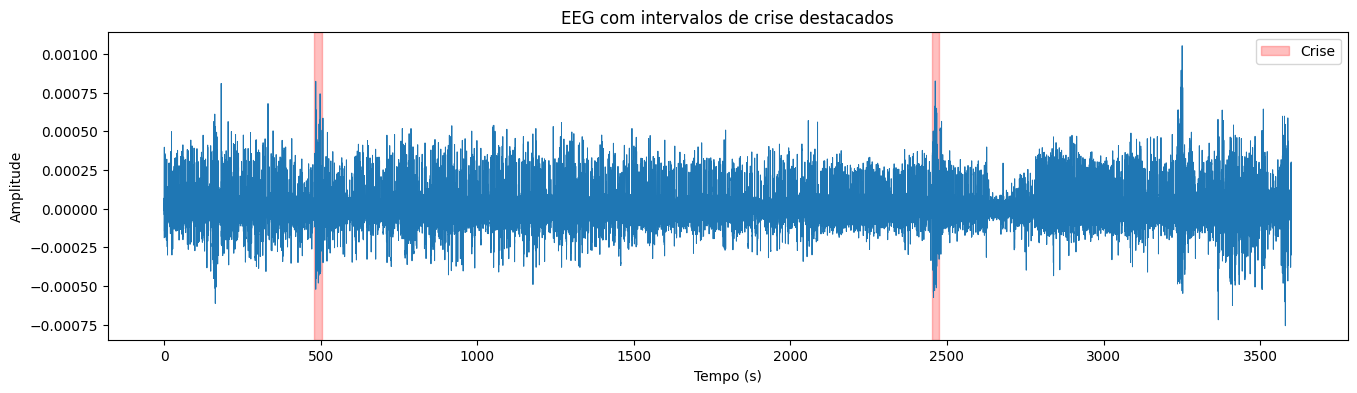

In [ ]:
plt.figure(figsize=(16,4))
plt.plot(time, signal, linewidth=0.7)

for i,(start, end) in enumerate(seizure_intervals_sec):
    plt.axvspan(start, end, color="red", alpha=0.25,
                label="Crise" if i==0 else None)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG com intervalos de crise destacados")
plt.legend()
plt.show()

In [ ]:
window_size = 256
step = 128

windows = []

for start in range(0, data_filtrado.shape[1] - window_size, step):
    segment = data_filtrado[:, start:start + window_size]
    windows.append(segment)

windows = np.array(windows)
windows.shape

(7198, 23, 256)

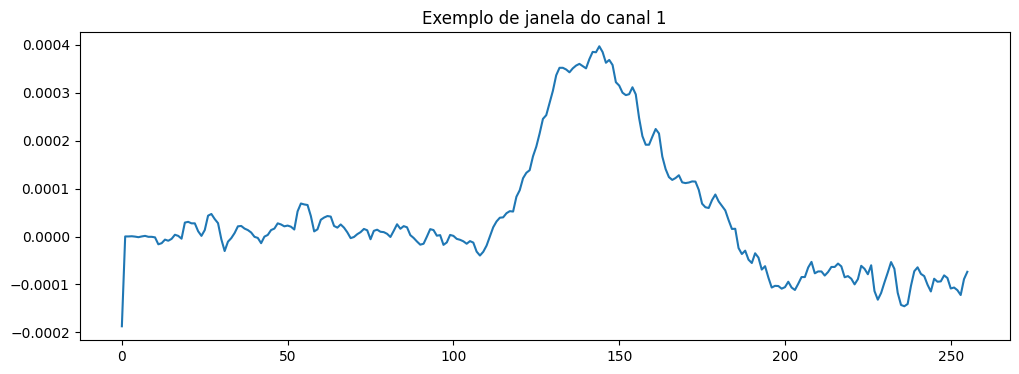

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(windows[0][0])
plt.title("Exemplo de janela do canal 1")
plt.show()

In [ ]:
print("Quantidade de janelas: ", windows.shape[0])
print("Canais por janela", windows.shape[1])
print("Pontos por janela", windows.shape[2])

Quantidade de janelas:  7198
Canais por janela 23
Pontos por janela 256
